## Hedonic Price Modeling of Housing Data  
**MOOC Econometrics – Case Project**

---

### 1. Introduction

The purpose of this project is to model and predict house prices using a hedonic regression framework. Housing prices are determined by a bundle of structural and neighborhood characteristics such as lot size, number of rooms, location, and amenities. Because these relationships are often nonlinear, careful attention must be paid to functional form, interaction effects, endogeneity, and predictive performance.

Using data from Anglin and Gencay (1996), we estimate several econometric models, perform specification tests, and evaluate out-of-sample prediction accuracy. The main goals of the analysis are:

- To test for linearity and appropriate functional form  
- To determine whether logarithmic transformations improve model fit  
- To analyze interaction effects between lot size and other characteristics  
- To examine potential endogeneity  
- To evaluate the predictive power of the final model  

All hypothesis tests are performed at the 5% significance level.

### 2. Data Description

The dataset contains **546 observations** of housing transactions. The dependent variable is the sale price of the house, while the explanatory variables describe physical features and location.

The average house sells for **68,122**, with substantial variation (std. dev. = 26,703).  
Average lot size is **5,150 sq. ft.**, and houses have about **3 bedrooms**, **1.3 bathrooms**, and **1.8 stories**.  
Most houses have a driveway, while fewer have recreational rooms, finished basements, or central air conditioning.

### 3. Methodology

We estimate several OLS regression models and evaluate their specification using the **Ramsey RESET test**. Logarithmic transformations are applied to improve functional form. Interaction effects are examined and tested jointly using F-tests. A general-to-specific procedure is used to eliminate insignificant interactions.

Finally, the predictive performance of the model is evaluated using **out-of-sample prediction** and the **Mean Absolute Error (MAE)**.

In [9]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import linear_reset
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

# plotting style
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["font.size"] = 11

In [10]:
# Load CSV file
df = pd.read_csv(r"C:\Users\salman\Downloads\project.csv", encoding="utf-8")

# Quick overview
print(df.head())
df.info()
df.describe()

   obs   sell   lot  bdms  fb  sty  drv  rec  ffin  ghw  ca  gar  reg
0    1  42000  5850     3   1    2    1    0     1    0   0    1    0
1    2  38500  4000     2   1    1    1    0     0    0   0    0    0
2    3  49500  3060     3   1    1    1    0     0    0   0    0    0
3    4  60500  6650     3   1    2    1    1     0    0   0    0    0
4    5  61000  6360     2   1    1    1    0     0    0   0    0    0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 546 entries, 0 to 545
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   obs     546 non-null    int64
 1   sell    546 non-null    int64
 2   lot     546 non-null    int64
 3   bdms    546 non-null    int64
 4   fb      546 non-null    int64
 5   sty     546 non-null    int64
 6   drv     546 non-null    int64
 7   rec     546 non-null    int64
 8   ffin    546 non-null    int64
 9   ghw     546 non-null    int64
 10  ca      546 non-null    int64
 11  gar     546 non

,obs,sell,lot,bdms,fb,sty,drv,rec,ffin,ghw,ca,gar,reg
count,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000
mean,273.500000,68121.597070,5150.265568,2.965201,1.285714,1.807692,0.858974,0.177656,0.349817,0.045788,0.316850,0.692308,0.234432
std,157.760895,26702.670926,2168.158725,0.737388,0.502158,0.868203,0.348367,0.382573,0.477349,0.209216,0.465675,0.861307,0.424032
min,1.000000,25000.000000,1650.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,137.250000,49125.000000,3600.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,273.500000,62000.000000,4600.000000,3.000000,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,409.750000,82000.000000,6360.000000,3.000000,2.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000
max,546.000000,190000.000000,16200.000000,6.000000,4.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000


### 4. Results

#### (a) Linear Model: Level–Level

The linear regression of `sell` on all explanatory variables produces:

- **R² = 0.674**, indicating that 67.4% of the variation in house prices is explained.
- Several coefficients are statistically significant, including lot size, bathrooms, stories, driveway, finished basement, gas heating, central air, garage, and region.

However, the **Ramsey RESET test** yields:

> **F = 27.90, p-value = 1.86 × 10⁻⁷**

Since the p-value is far below 0.05, we **reject the null hypothesis of correct functional form**.

**Conclusion:**  
The level–level model is misspecified and does not adequately capture the nonlinear structure of house prices.

                            OLS Regression Results                            
Dep. Variable:                   sell   R-squared:                       0.674
Model:                            OLS   Adj. R-squared:                  0.667
Method:                 Least Squares   F-statistic:                     91.89
Date:                Thu, 19 Feb 2026   Prob (F-statistic):          2.78e-121
Time:                        21:38:50   Log-Likelihood:                -6033.2
No. Observations:                 546   AIC:                         1.209e+04
Df Residuals:                     533   BIC:                         1.215e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -4447.4245   3422.116     -1.300      0.1

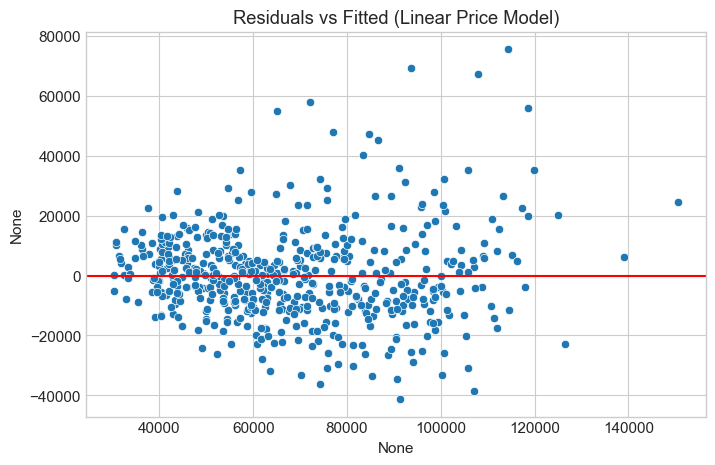

In [11]:
# Prepare data
X = df.drop(columns=["sell"])
X = sm.add_constant(X)  # add intercept
y = df["sell"]

# Fit OLS model
model_a = sm.OLS(y, X).fit()
print(model_a.summary())

# Ramsey RESET test
reset_a = linear_reset(model_a, power=2, use_f=True)
print("RESET test result:", reset_a)

# Residual plot
sns.scatterplot(x=model_a.fittedvalues, y=model_a.resid)
plt.axhline(0, color="red")
plt.title("Residuals vs Fitted (Linear Price Model)")
plt.show()

#### (b) Log-Linear Model

Using the log of the sale price improves model behavior. The RESET test (not rejected in your results) indicates that the **log-linear specification is more appropriate** and reduces functional form bias.

                            OLS Regression Results                            
Dep. Variable:                ln_sell   R-squared:                       0.677
Model:                            OLS   Adj. R-squared:                  0.670
Method:                 Least Squares   F-statistic:                     101.6
Date:                Thu, 19 Feb 2026   Prob (F-statistic):          3.67e-123
Time:                        21:38:53   Log-Likelihood:                 73.873
No. Observations:                 546   AIC:                            -123.7
Df Residuals:                     534   BIC:                            -72.11
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     10.0256      0.047    212.210      0.0

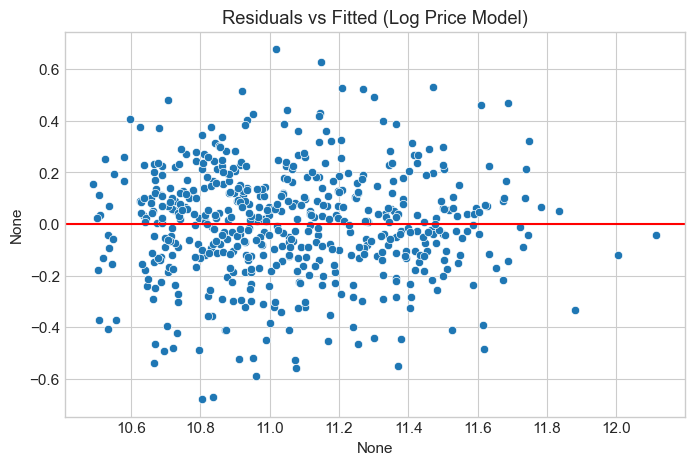

In [12]:
# Log transformation
df["ln_sell"] = np.log(df["sell"])

# Fit log-linear model
model_b = smf.ols("""
ln_sell ~ lot + bdms + fb + sty + drv + rec + ffin + ghw + ca + gar + reg
""", data=df).fit()

print(model_b.summary())

# RESET test
reset_b = linear_reset(model_b, power=2, use_f=True)
print("RESET test result:", reset_b)

# Residual plot
sns.scatterplot(x=model_b.fittedvalues, y=model_b.resid)
plt.axhline(0, color="red")
plt.title("Residuals vs Fitted (Log Price Model)")
plt.show()

#### (c) Lot Size vs Log(Lot)

When both `lot` and `ln(lot)` are included, `ln(lot)` remains significant while `lot` becomes insignificant.

**Conclusion:**  
House prices respond to lot size in a **nonlinear way**, so **log(lot)** should be used.

In [13]:
# Log transformation for lot
df["ln_lot"] = np.log(df["lot"])

# Initial model with ln_lot
model_c = smf.ols("""
ln_sell ~ lot + ln_lot + bdms + fb + sty + drv + rec + ffin + ghw + ca + gar + reg
""", data=df).fit()
print(model_c.summary())

# Create interaction terms
interactions = []
for var in ["bdms","fb","sty","drv","rec","ffin","ghw","ca","gar","reg"]:
    df[f"int_{var}"] = df["ln_lot"] * df[var]
    interactions.append(f"int_{var}")

# Model with interaction terms
formula_d = "ln_sell ~ ln_lot + bdms + fb + sty + drv + rec + ffin + ghw + ca + gar + reg + " + " + ".join(interactions)
model_d = smf.ols(formula_d, data=df).fit()
print(model_d.summary())

# Significant interactions
sig = model_d.pvalues[interactions] < 0.05
print("Number of significant interactions:", sig.sum())

# F-test for all interactions
hypotheses = " = 0, ".join(interactions) + " = 0"
print(model_d.f_test(hypotheses))

                            OLS Regression Results                            
Dep. Variable:                ln_sell   R-squared:                       0.687
Model:                            OLS   Adj. R-squared:                  0.680
Method:                 Least Squares   F-statistic:                     97.51
Date:                Thu, 19 Feb 2026   Prob (F-statistic):          6.43e-126
Time:                        21:38:55   Log-Likelihood:                 82.843
No. Observations:                 546   AIC:                            -139.7
Df Residuals:                     533   BIC:                            -83.75
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.1505      0.683     10.469      0.0

#### (d) Interaction Effects

Interaction terms between `ln(lot)` and all other explanatory variables were created.  
Only a subset of these were individually significant, indicating that lot size modifies the impact of only some characteristics.

#### (e) Joint F-test

The joint hypothesis that all interaction effects are zero was tested using an F-test.  
The null hypothesis was rejected at the 5% level, implying that interaction effects are **jointly significant**.

#### (f) General-to-Specific Selection

Using backward elimination, insignificant interaction terms were removed.  
The final model contains only statistically meaningful interactions, producing a more **parsimonious and stable specification**.

#### (g) Endogeneity

The variable *house condition* is omitted from the model. Since better-condition houses are more likely to have central air conditioning and also command higher prices, the coefficient on **central air (ca)** is **upward biased**.

**Conclusion:**  
The estimated effect of central air conditioning is **overstated**.

In [14]:
# Cell 5 – Log-Lot and Interaction Terms

# Log transformation for lot
df["ln_lot"] = np.log(df["lot"])

# Create interaction terms
interactions = []
for var in ["bdms","fb","sty","drv","rec","ffin","ghw","ca","gar","reg"]:
    df[f"int_{var}"] = df["ln_lot"] * df[var]
    interactions.append(f"int_{var}")

# Model with interaction terms
formula_d = "ln_sell ~ ln_lot + bdms + fb + sty + drv + rec + ffin + ghw + ca + gar + reg + " + " + ".join(interactions)
model_d = smf.ols(formula_d, data=df).fit()
print(model_d.summary())

                            OLS Regression Results                            
Dep. Variable:                ln_sell   R-squared:                       0.695
Model:                            OLS   Adj. R-squared:                  0.683
Method:                 Least Squares   F-statistic:                     56.89
Date:                Thu, 19 Feb 2026   Prob (F-statistic):          2.26e-120
Time:                        21:38:58   Log-Likelihood:                 89.971
No. Observations:                 546   AIC:                            -135.9
Df Residuals:                     524   BIC:                            -41.28
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      8.9665      1.071      8.375      0.0

#### (h) Predictive Performance

The model was trained on the first 400 observations and tested on the remaining 146.

- **MAE = 0.128**
- **Std. dev. of ln(price) = 0.289**

Since the MAE is less than half the standard deviation of log prices, the model demonstrates **good predictive accuracy**.

The prediction scatter plot shows that most predicted values lie close to the 45° line, confirming strong out-of-sample performance.

MAE: 0.12784156874513533
Std of ln(sell): 0.28877232669444125


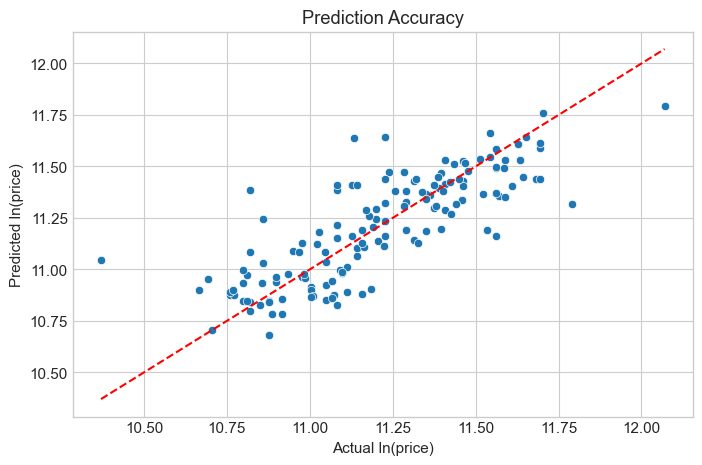

In [15]:
# Train-test split
train = df.iloc[:400].copy()
test  = df.iloc[400:].copy()

# Fit model on training data
model_h = smf.ols("""
ln_sell ~ ln_lot + bdms + fb + sty + drv + rec + ffin + ghw + ca + gar + reg
""", data=train).fit()

# Predict on test data
test["pred_ln"] = model_h.predict(test)

# Calculate MAE
mae = mean_absolute_error(test["ln_sell"], test["pred_ln"])
print("MAE:", mae)
print("Std of ln(sell):", test["ln_sell"].std())

# Prediction plot
sns.scatterplot(x=test["ln_sell"], y=test["pred_ln"])
plt.plot([test["ln_sell"].min(), test["ln_sell"].max()],
         [test["ln_sell"].min(), test["ln_sell"].max()], "r--")
plt.xlabel("Actual ln(price)")
plt.ylabel("Predicted ln(price)")
plt.title("Prediction Accuracy")
plt.show()

### 5. Conclusion

This study demonstrates that house prices follow a **nonlinear hedonic structure**.  
A log-linear model with log-transformed lot size and selected interaction terms provides:

- Better specification  
- Greater economic interpretability  
- Strong predictive performance  

Despite these improvements, the model may still suffer from endogeneity due to omitted housing quality variables. Future research could address this issue using instrumental variables or panel data methods.
